In [16]:
# based on seisbench example code
import obspy
import seisbench
import seisbench.models as sbm
import util
import os
import pickle
import setup_paths as paths
import matplotlib.pyplot as plt


In [5]:

root_path = '/home/earthquakes1/homes/Rebecca/phd/data/'

subfolders = ['2018_2021_global_m5']


In [9]:
folder = subfolders[0]

root = os.path.join(root_path, folder)
seisbench.use_backup_repository()
# load EQT model
model = sbm.EQTransformer.from_pretrained("original", update=True)

# print model weights
print(model.weights_docstring)

def save_obj(obj, eq_name):
	with open(root + '/' + eq_name + '/picks_for_uncertainty.pkl', 'wb') as f:
		pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)


2025-03-24 14:38:42,217 | seisbench | WARNING | Setting remote root to: https://seisbench.gfz-potsdam.de/mirror/
Please note that this can affect your download speed.


Original (conservative) EQTransformer model from Mousavi et al. (2020). Originally published under MIT License. Original available at https://github.com/smousavi05/EQTransformer/blob/01bf112a00c1a3bbb43adb2c7dba3e21b5fbcdb9/ModelsAndSampleData/EqT_model_conservative.h5 . 

Converted to SeisBench by Jannes Münchmeyer (munchmej@gfz-potsdam.de) and Calum Chamberlain (calum.chamberlain@vuw.ac.nz).


/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/seisbench/models/base.py:489: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights

In [10]:

print('===load cat===')
cat = obspy.read_events(root + '_catalog.xml')


===load cat===


In [26]:
event

Event:	2021-12-01T04:39:24.977000Z | -37.922,  -73.619 | 5.1  Mww

	            resource_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?eventid=11502861")
	             event_type: 'earthquake'
	    preferred_origin_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?originid=46160336")
	 preferred_magnitude_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?magnitudeid=208426474")
	                   ---------
	     event_descriptions: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements

In [27]:

print('===eq with data===')
# find which earthquakes have data and station responses
eq_with_data = []
mags = []
for event in cat:
	eq_name = util.catEventToFileName(event)
	
	print(eq_name)
	print(os.path.isdir(root + '/' + eq_name))
	print(os.path.isdir(root + '/' + eq_name + '/station_xml_files'))
	if os.path.isdir(root + '/' + eq_name) and os.path.isdir(root + '/' + eq_name + '/station_xml_files'):
		eq_with_data.append(eq_name)
		mags.append(event.magnitudes[0].mag)
print(eq_with_data)


===eq with data===
20180131_231321.a
False
False
20180131_200145.a
False
False
20180131_191551.a
False
False
20180131_164152.a
False
False
20180131_163705.a
False
False
20180131_152650.a
False
False
20180131_114939.a
False
False
20180131_070700.a
False
False
20180131_031310.a
False
False
20180131_020031.a
True
False
20180130_192419.a
True
True
20180130_142352.a
False
False
20180130_114928.a
False
False
20180129_162553.a
True
False
20180128_235314.a
False
False
20180128_224616.a
False
False
20180128_222336.a
False
False
20180128_180944.a
False
False
20180128_160303.a
False
False
20180128_101126.a
True
False
20180128_072926.a
False
False
20180128_021814.a
False
False
20180128_001129.a
False
False
20180128_000853.a
False
False
20180127_214512.a
False
False
20180127_022357.a
False
False
20180126_225210.a
False
False
20180126_224757.a
False
False
20180126_164204.a
False
False
20180126_132706.a
False
False
20180126_104345.a
True
False
20180126_072834.a
False
False
20180126_010929.a
False
Fal

In [12]:

count = 0
# for each earthquake with data, pick P wave and save picks
for eq_name in eq_with_data[0:1]:
	try:
		print(eq_name)
		if os.path.exists(root + '/' + eq_name + '/picks_for_uncertainty.pkl') is False:
			print('earthquake number' + str(count) + 'done. It was' + eq_name)
			stream = obspy.read(root + '/' + eq_name + '/data/*/*')

			output = model.classify(stream)
			picks = output.picks
			detections = output.detections

			# interpret and save picks in pickled dictionary
			picks_dict = {}
			picks_samples = {}
			for pick in picks:
				pick_dist = stream[0].stats.starttime - pick.peak_time
				if (pick.phase == 'P'
						and pick.trace_id not in picks_dict.keys()
						and abs(pick_dist) > 200 and abs(pick_dist) < 400):
					picks_dict[pick.trace_id] = pick.peak_time
				elif pick.phase == 'P' and pick.trace_id in picks_dict.keys():
					current_pick = picks_dict[pick.trace_id]
					current_dist = stream[0].stats.starttime - current_pick
					min_dist = min([current_dist, pick_dist], key=lambda x: abs(abs(x) - 300))
					if min_dist == pick_dist:
						picks_dict[pick.trace_id] = pick.peak_time
						picks_samples[pick.trace_id] = pick.peak_time - stream[0].stats.starttime
					else:
						continue
				else:
					continue
			count += 1
			save_obj(picks_dict, eq_name)
			print('SAVED')
		else:
			print('already done')
			print(eq_name)
	except Exception:
		print('unsuitable in some way, onto next earthquake')
		continue


20180130_192419.a
already done
20180130_192419.a


20180130_192419.a
39 Trace(s) in Stream:

7L.G1..EQTransformer_Detection | 2018-01-30T19:19:13.820000Z - 2018-01-30T19:29:23.980000Z | 100.0 Hz, 61017 samples
...
(37 other traces)
...
OR.SVIN.00.EQTransformer_S | 2018-01-30T19:19:22.990000Z - 2018-01-30T19:29:15.520000Z | 100.0 Hz, 59254 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
earthquake number0done. It was20180130_192419.a


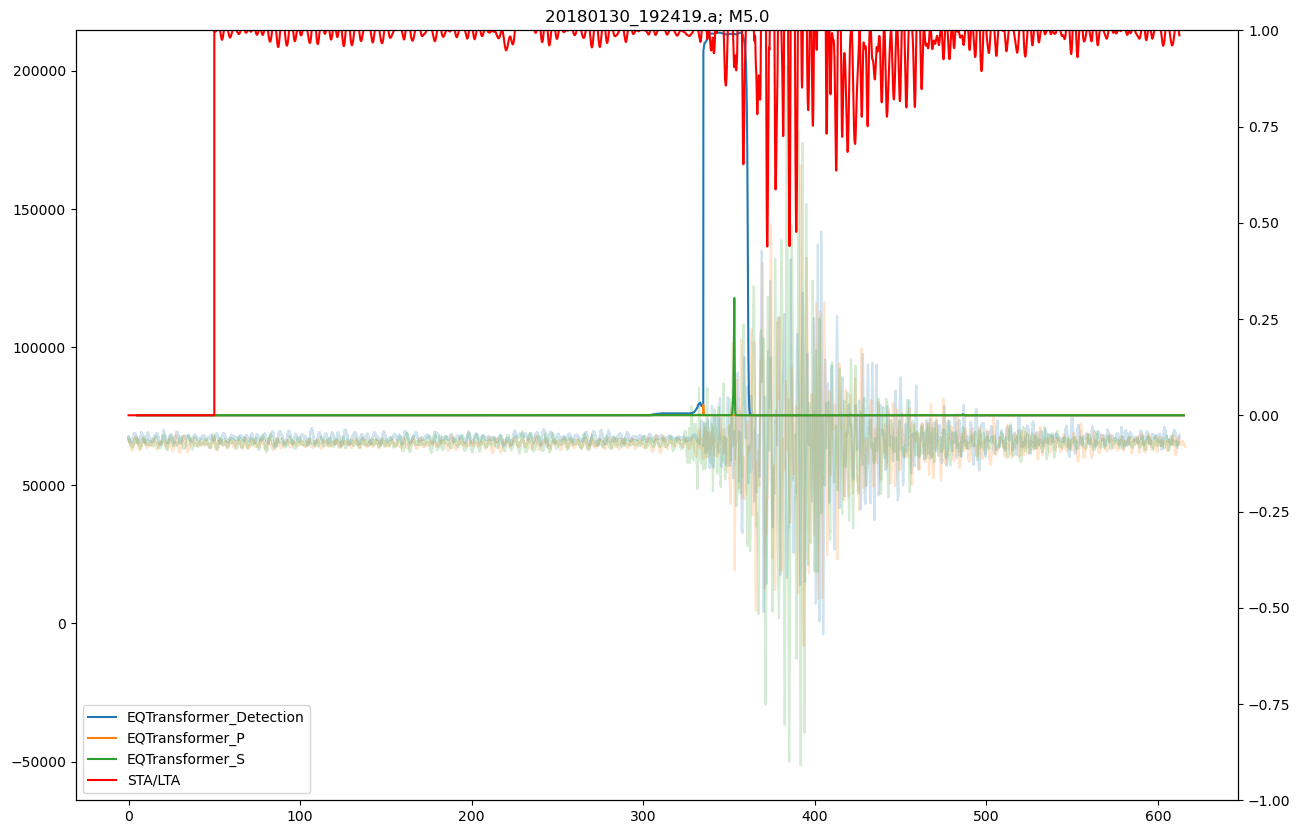

20180125_172434.a
12 Trace(s) in Stream:
BK.JCC.00.EQTransformer_Detection | 2018-01-25T17:19:39.120000Z - 2018-01-25T17:29:29.110000Z | 100.0 Hz, 59000 samples
BK.JCC.00.EQTransformer_P         | 2018-01-25T17:19:39.120000Z - 2018-01-25T17:29:29.110000Z | 100.0 Hz, 59000 samples
BK.JCC.00.EQTransformer_S         | 2018-01-25T17:19:39.120000Z - 2018-01-25T17:29:29.110000Z | 100.0 Hz, 59000 samples
NC.KCT..EQTransformer_Detection   | 2018-01-25T17:19:39.110000Z - 2018-01-25T17:29:29.100000Z | 100.0 Hz, 59000 samples
NC.KCT..EQTransformer_P           | 2018-01-25T17:19:39.110000Z - 2018-01-25T17:29:29.100000Z | 100.0 Hz, 59000 samples
NC.KCT..EQTransformer_S           | 2018-01-25T17:19:39.110000Z - 2018-01-25T17:29:29.100000Z | 100.0 Hz, 59000 samples
NC.KMPB..EQTransformer_Detection  | 2018-01-25T17:19:39.110000Z - 2018-01-25T17:29:29.100000Z | 100.0 Hz, 59000 samples
NC.KMPB..EQTransformer_P          | 2018-01-25T17:19:39.110000Z - 2018-01-25T17:29:29.100000Z | 100.0 Hz, 59000 samples

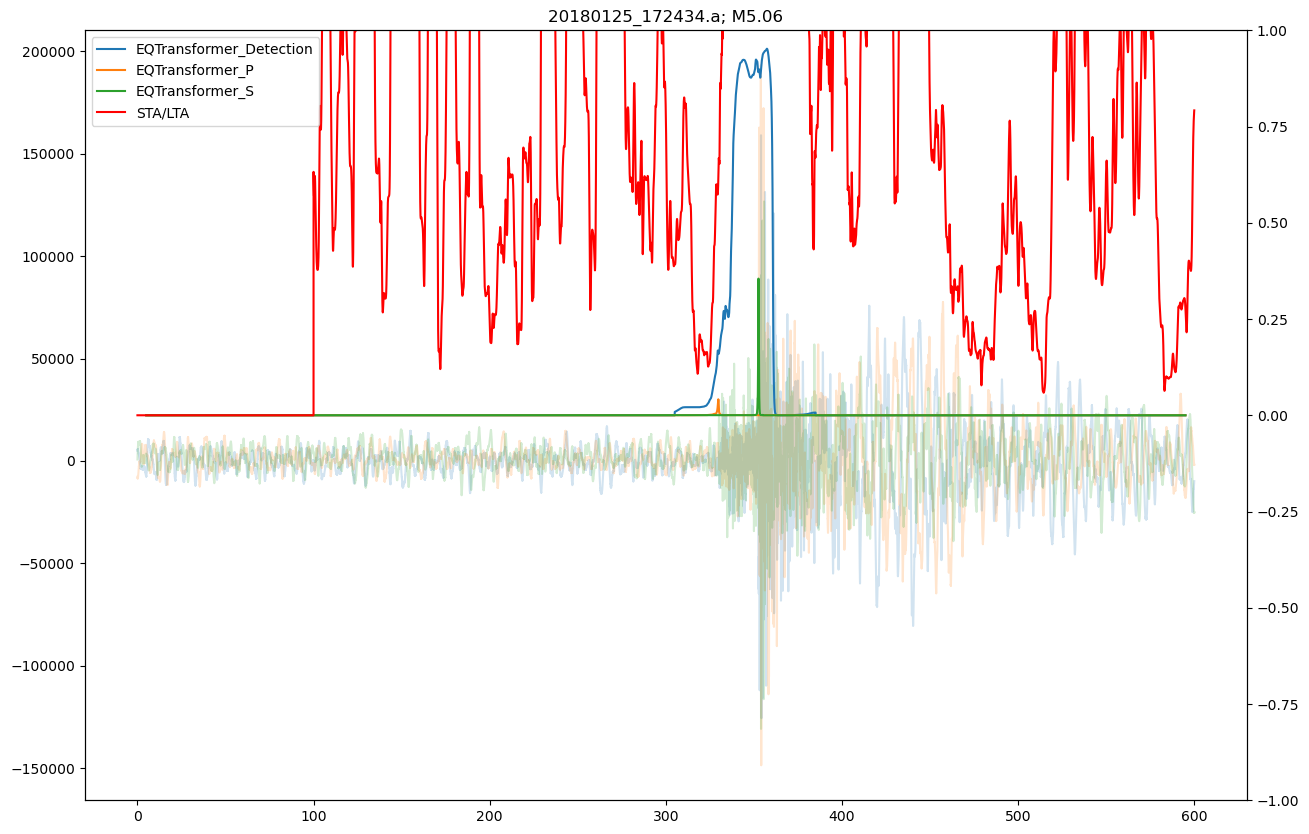

20180125_163943.a
12 Trace(s) in Stream:
BK.JCC.00.EQTransformer_Detection | 2018-01-25T16:34:48.510000Z - 2018-01-25T16:44:38.500000Z | 100.0 Hz, 59000 samples
BK.JCC.00.EQTransformer_P         | 2018-01-25T16:34:48.510000Z - 2018-01-25T16:44:38.500000Z | 100.0 Hz, 59000 samples
BK.JCC.00.EQTransformer_S         | 2018-01-25T16:34:48.510000Z - 2018-01-25T16:44:38.500000Z | 100.0 Hz, 59000 samples
NC.KCT..EQTransformer_Detection   | 2018-01-25T16:34:48.500000Z - 2018-01-25T16:44:38.490000Z | 100.0 Hz, 59000 samples
NC.KCT..EQTransformer_P           | 2018-01-25T16:34:48.500000Z - 2018-01-25T16:44:38.490000Z | 100.0 Hz, 59000 samples
NC.KCT..EQTransformer_S           | 2018-01-25T16:34:48.500000Z - 2018-01-25T16:44:38.490000Z | 100.0 Hz, 59000 samples
NC.KMPB..EQTransformer_Detection  | 2018-01-25T16:34:48.500000Z - 2018-01-25T16:44:38.490000Z | 100.0 Hz, 59000 samples
NC.KMPB..EQTransformer_P          | 2018-01-25T16:34:48.500000Z - 2018-01-25T16:44:38.490000Z | 100.0 Hz, 59000 samples

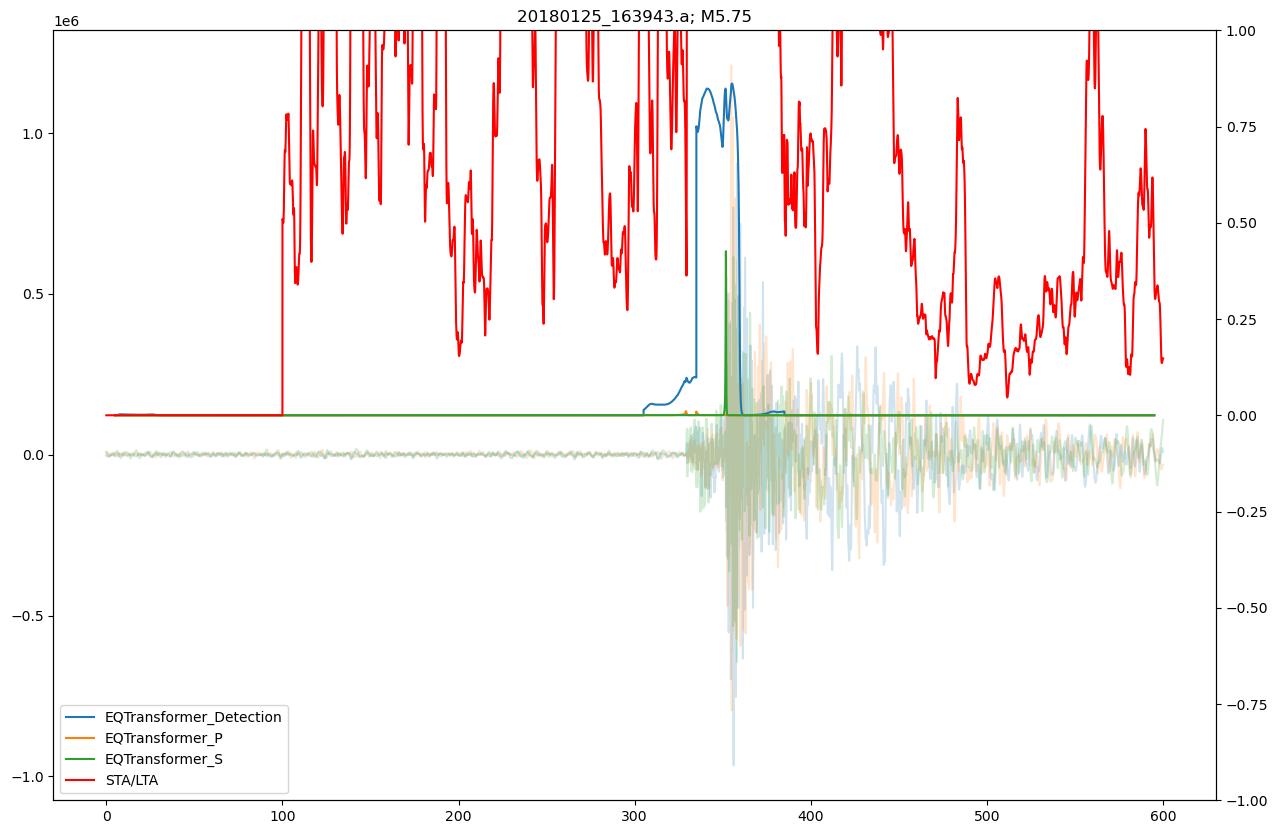

20180124_074605.a
51 Trace(s) in Stream:

CX.HMBCX..EQTransformer_Detection | 2018-01-24T07:40:12.620000Z - 2018-01-24T07:51:34.190000Z | 100.0 Hz, 68158 samples
...
(49 other traces)
...
IQ.UNAP..EQTransformer_S | 2018-01-24T07:40:57.140000Z - 2018-01-24T07:51:18.790000Z | 100.0 Hz, 62166 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
earthquake number3done. It was20180124_074605.a


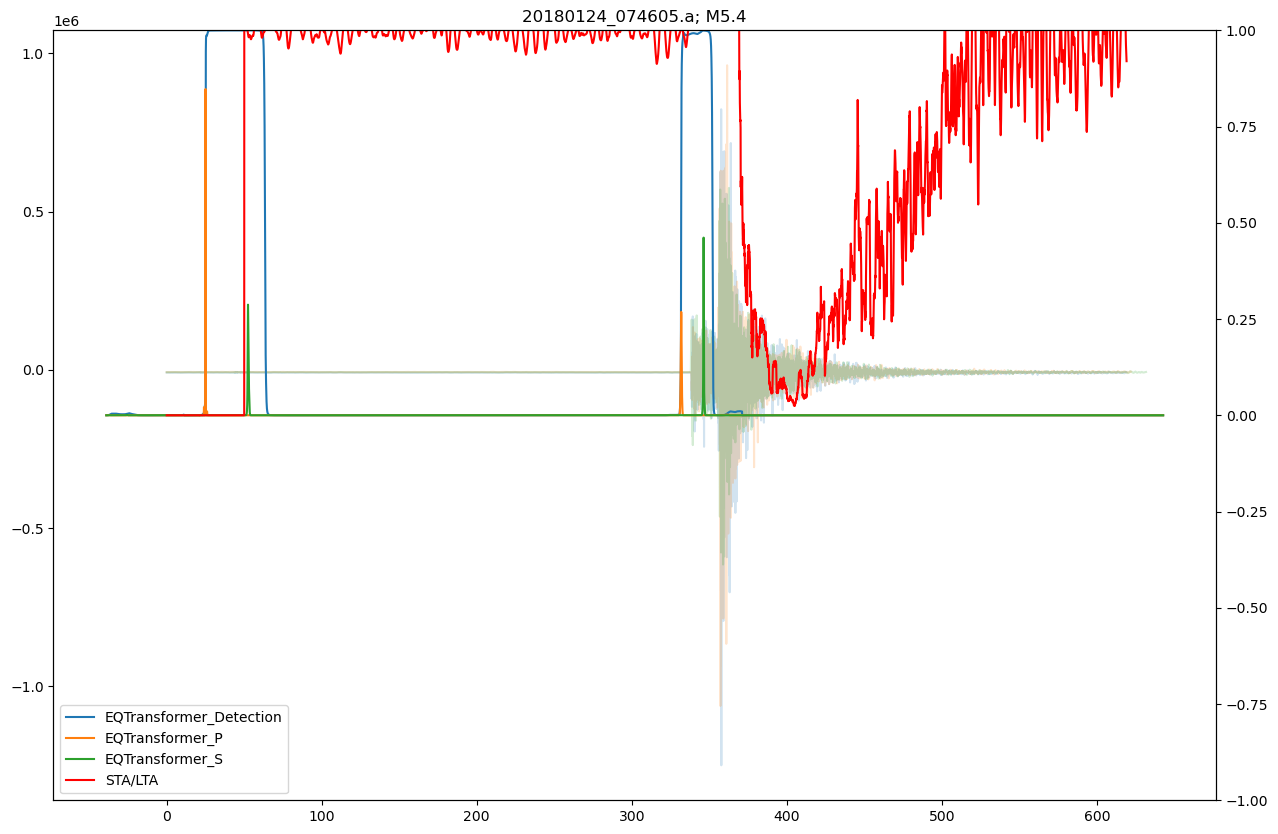

20180121_190602.a
18 Trace(s) in Stream:
GE.BOAB..EQTransformer_Detection | 2018-01-21T19:01:05.200000Z - 2018-01-21T19:10:59.920000Z | 100.0 Hz, 59473 samples
GE.BOAB..EQTransformer_P         | 2018-01-21T19:01:05.200000Z - 2018-01-21T19:10:59.920000Z | 100.0 Hz, 59473 samples
GE.BOAB..EQTransformer_S         | 2018-01-21T19:01:05.200000Z - 2018-01-21T19:10:59.920000Z | 100.0 Hz, 59473 samples
NU.ACON..EQTransformer_Detection | 2018-01-21T19:01:05.610000Z - 2018-01-21T19:10:59.250000Z | 100.0 Hz, 59365 samples
NU.ACON..EQTransformer_P         | 2018-01-21T19:01:05.610000Z - 2018-01-21T19:10:59.250000Z | 100.0 Hz, 59365 samples
NU.ACON..EQTransformer_S         | 2018-01-21T19:01:05.610000Z - 2018-01-21T19:10:59.250000Z | 100.0 Hz, 59365 samples
NU.BOAB..EQTransformer_Detection | 2018-01-21T19:01:05.200000Z - 2018-01-21T19:10:59.920000Z | 100.0 Hz, 59473 samples
NU.BOAB..EQTransformer_P         | 2018-01-21T19:01:05.200000Z - 2018-01-21T19:10:59.920000Z | 100.0 Hz, 59473 samples
NU.BOAB

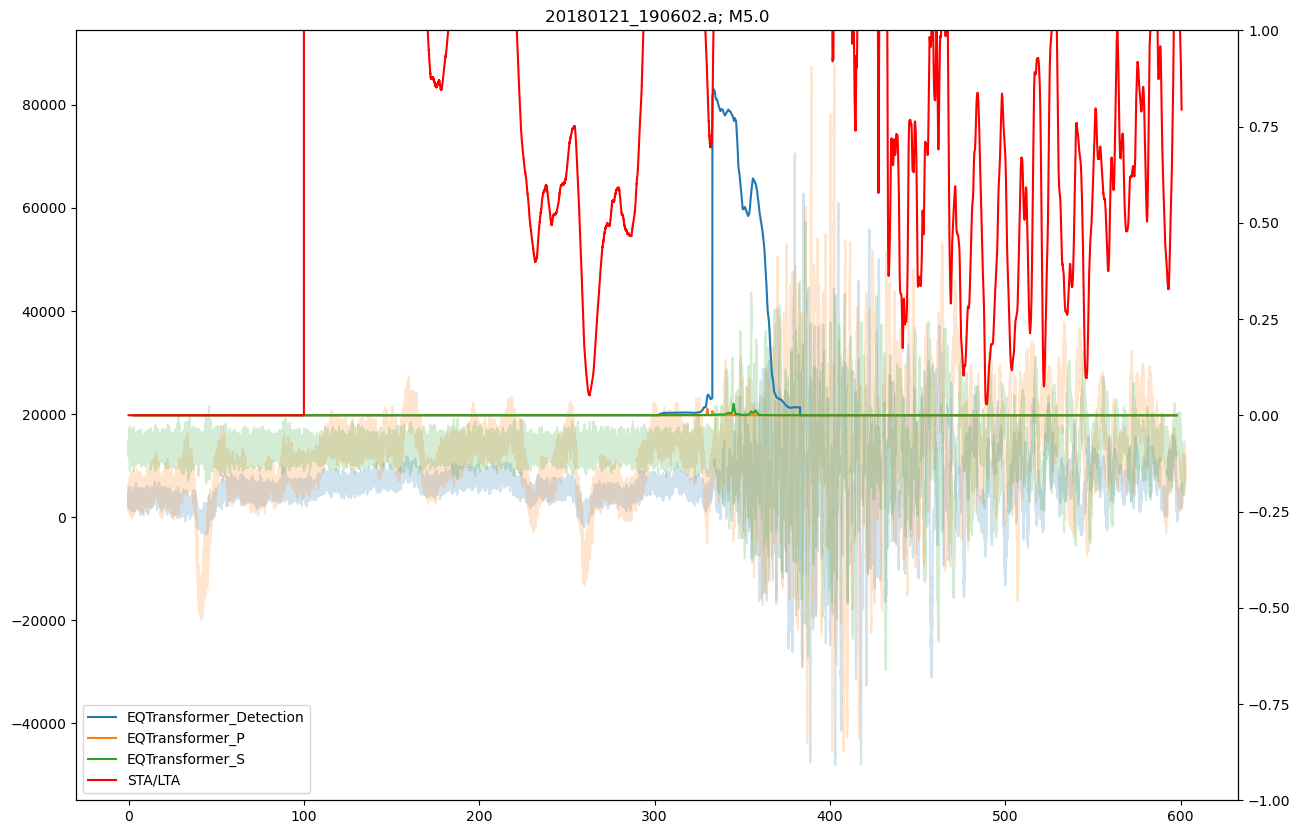

20180121_010642.a
39 Trace(s) in Stream:

CX.HMBCX..EQTransformer_Detection | 2018-01-21T01:00:46.020000Z - 2018-01-21T01:11:52.880000Z | 100.0 Hz, 66687 samples
...
(37 other traces)
...
IQ.UNAP..EQTransformer_S | 2018-01-21T01:01:39.420000Z - 2018-01-21T01:11:45.580000Z | 100.0 Hz, 60617 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
earthquake number5done. It was20180121_010642.a


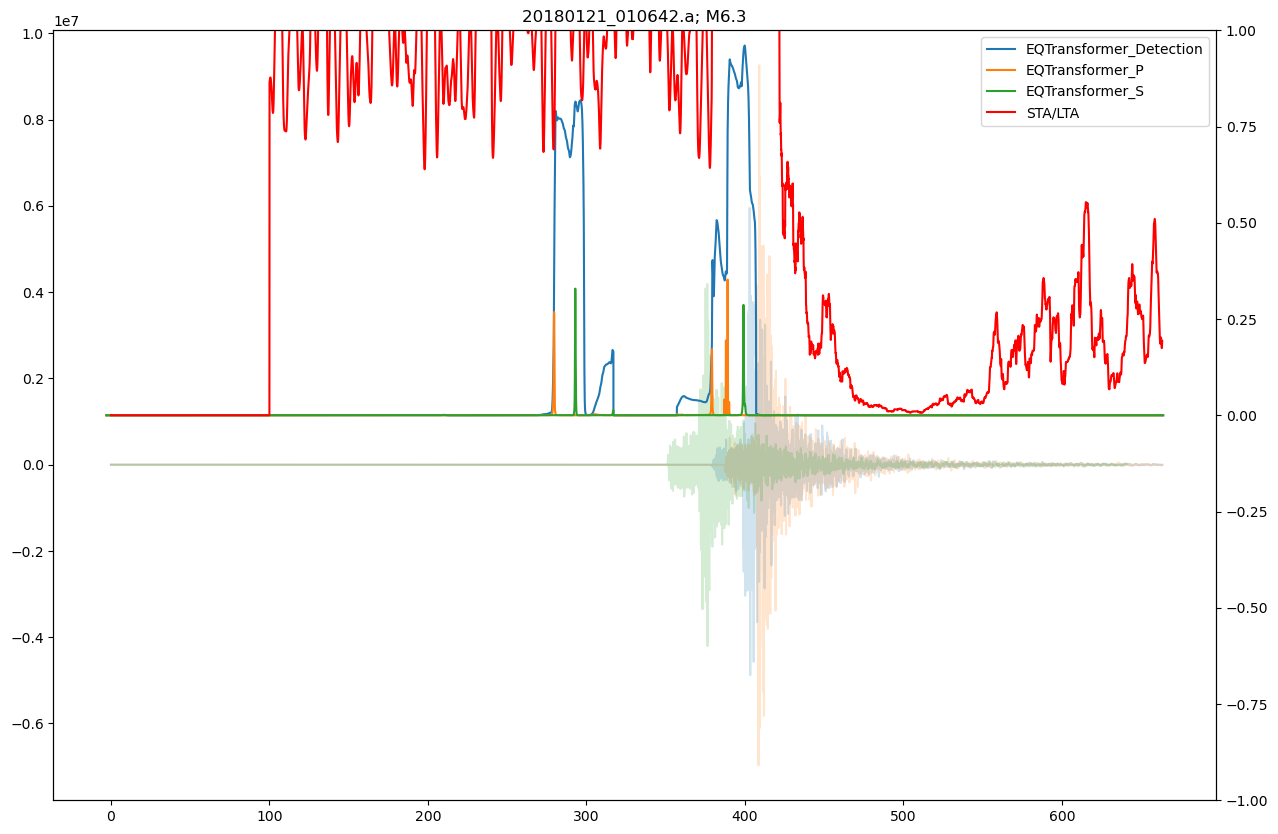

20180117_225659.a
6 Trace(s) in Stream:
NZ.GLKZ.10.EQTransformer_Detection | 2018-01-17T22:52:01.180000Z - 2018-01-17T23:01:56.530000Z | 100.0 Hz, 59536 samples
NZ.GLKZ.10.EQTransformer_P         | 2018-01-17T22:52:01.180000Z - 2018-01-17T23:01:56.530000Z | 100.0 Hz, 59536 samples
NZ.GLKZ.10.EQTransformer_S         | 2018-01-17T22:52:01.180000Z - 2018-01-17T23:01:56.530000Z | 100.0 Hz, 59536 samples
NZ.RIZ.10.EQTransformer_Detection  | 2018-01-17T22:52:02.960000Z - 2018-01-17T23:01:56.260000Z | 100.0 Hz, 59331 samples
NZ.RIZ.10.EQTransformer_P          | 2018-01-17T22:52:02.960000Z - 2018-01-17T23:01:56.260000Z | 100.0 Hz, 59331 samples
NZ.RIZ.10.EQTransformer_S          | 2018-01-17T22:52:02.960000Z - 2018-01-17T23:01:56.260000Z | 100.0 Hz, 59331 samples
earthquake number6done. It was20180117_225659.a


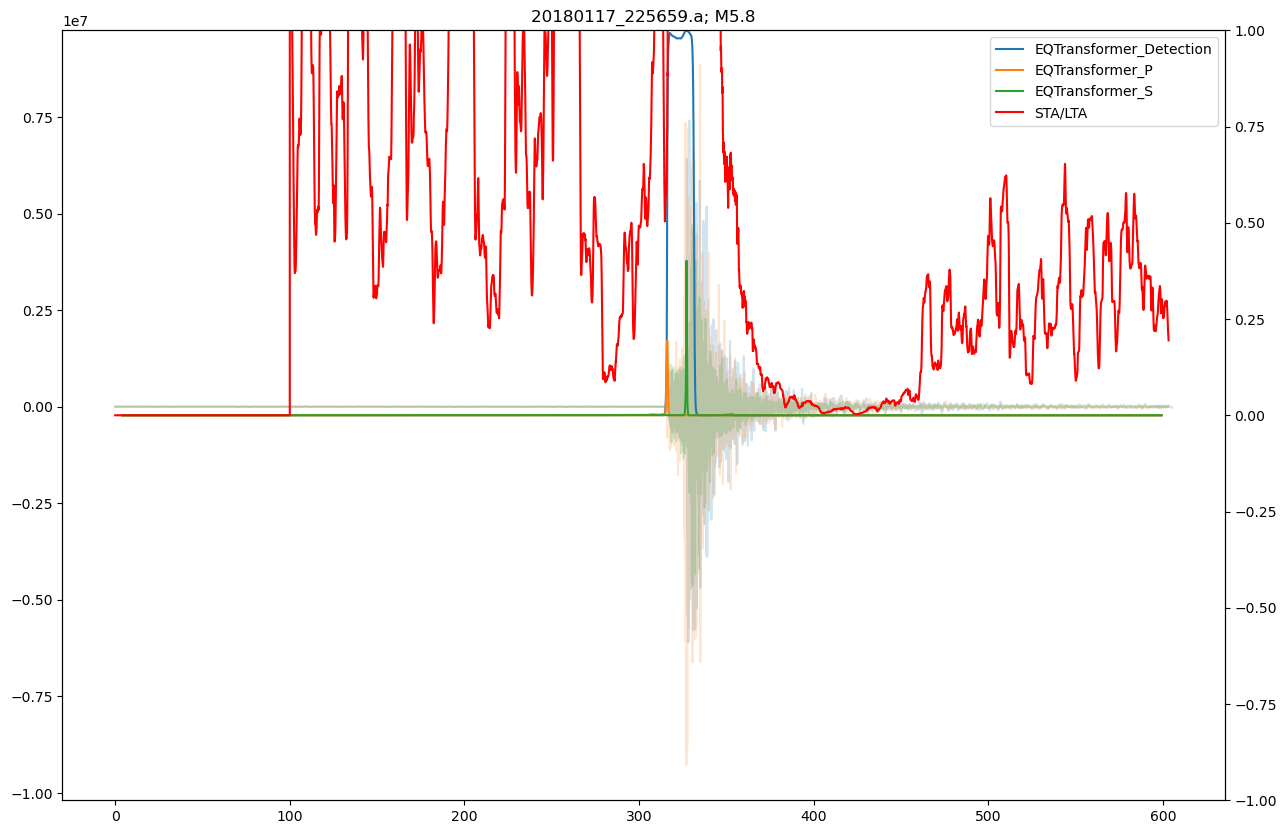

20180116_150353.a
12 Trace(s) in Stream:
NU.ACON..EQTransformer_Detection | 2018-01-16T14:58:56.430000Z - 2018-01-16T15:08:49.450000Z | 100.0 Hz, 59303 samples
NU.ACON..EQTransformer_P         | 2018-01-16T14:58:56.430000Z - 2018-01-16T15:08:49.450000Z | 100.0 Hz, 59303 samples
NU.ACON..EQTransformer_S         | 2018-01-16T14:58:56.430000Z - 2018-01-16T15:08:49.450000Z | 100.0 Hz, 59303 samples
NU.CNGN..EQTransformer_Detection | 2018-01-16T14:58:57.280000Z - 2018-01-16T15:08:49.890000Z | 100.0 Hz, 59262 samples
NU.CNGN..EQTransformer_P         | 2018-01-16T14:58:57.280000Z - 2018-01-16T15:08:49.890000Z | 100.0 Hz, 59262 samples
NU.CNGN..EQTransformer_S         | 2018-01-16T14:58:57.280000Z - 2018-01-16T15:08:49.890000Z | 100.0 Hz, 59262 samples
NU.CRIN..EQTransformer_Detection | 2018-01-16T14:58:56.570000Z - 2018-01-16T15:08:49.270000Z | 100.0 Hz, 59271 samples
NU.CRIN..EQTransformer_P         | 2018-01-16T14:58:56.570000Z - 2018-01-16T15:08:49.270000Z | 100.0 Hz, 59271 samples
NU.CRIN

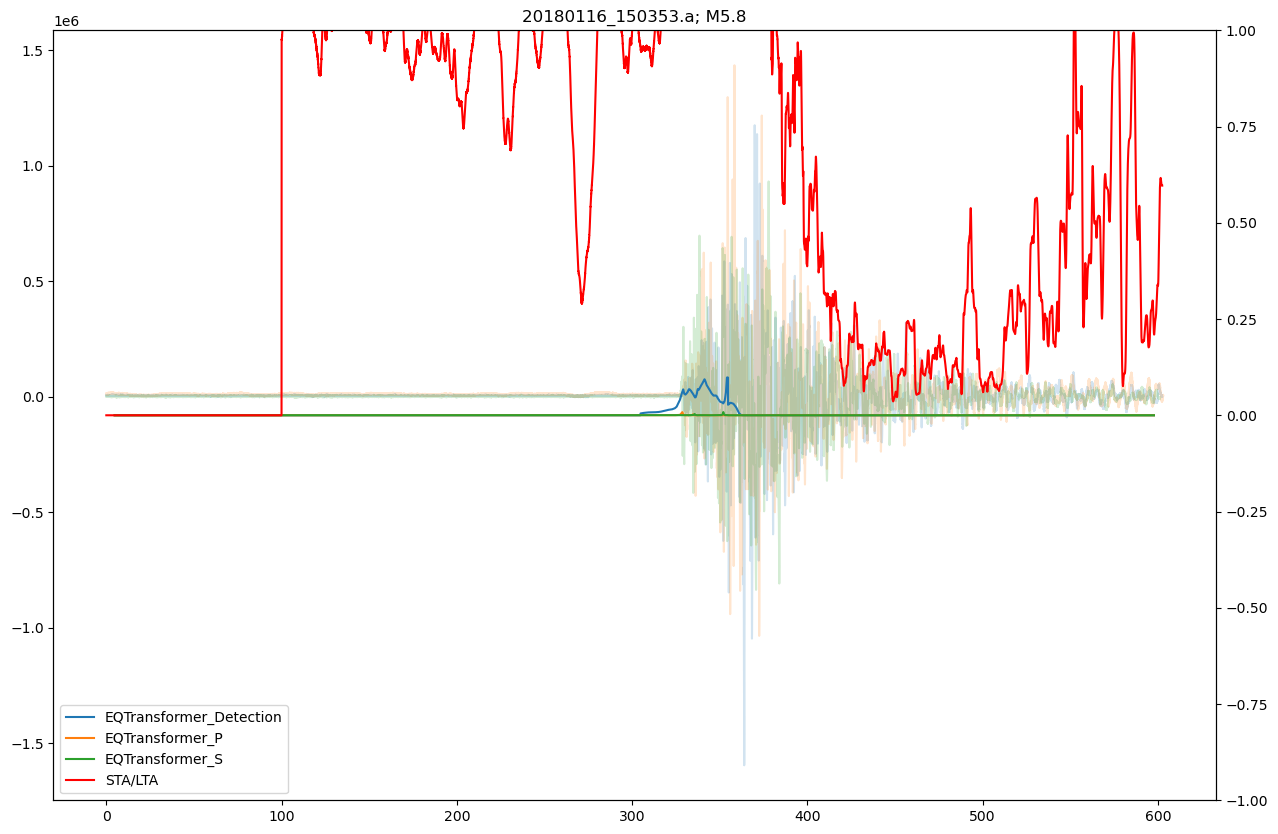

20180115_081823.a
3 Trace(s) in Stream:
G.FUTU.00.EQTransformer_Detection | 2018-01-15T08:12:03.550000Z - 2018-01-15T08:24:34.490000Z | 100.0 Hz, 75095 samples
G.FUTU.00.EQTransformer_P         | 2018-01-15T08:12:03.550000Z - 2018-01-15T08:24:34.490000Z | 100.0 Hz, 75095 samples
G.FUTU.00.EQTransformer_S         | 2018-01-15T08:12:03.550000Z - 2018-01-15T08:24:34.490000Z | 100.0 Hz, 75095 samples
earthquake number8done. It was20180115_081823.a


/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


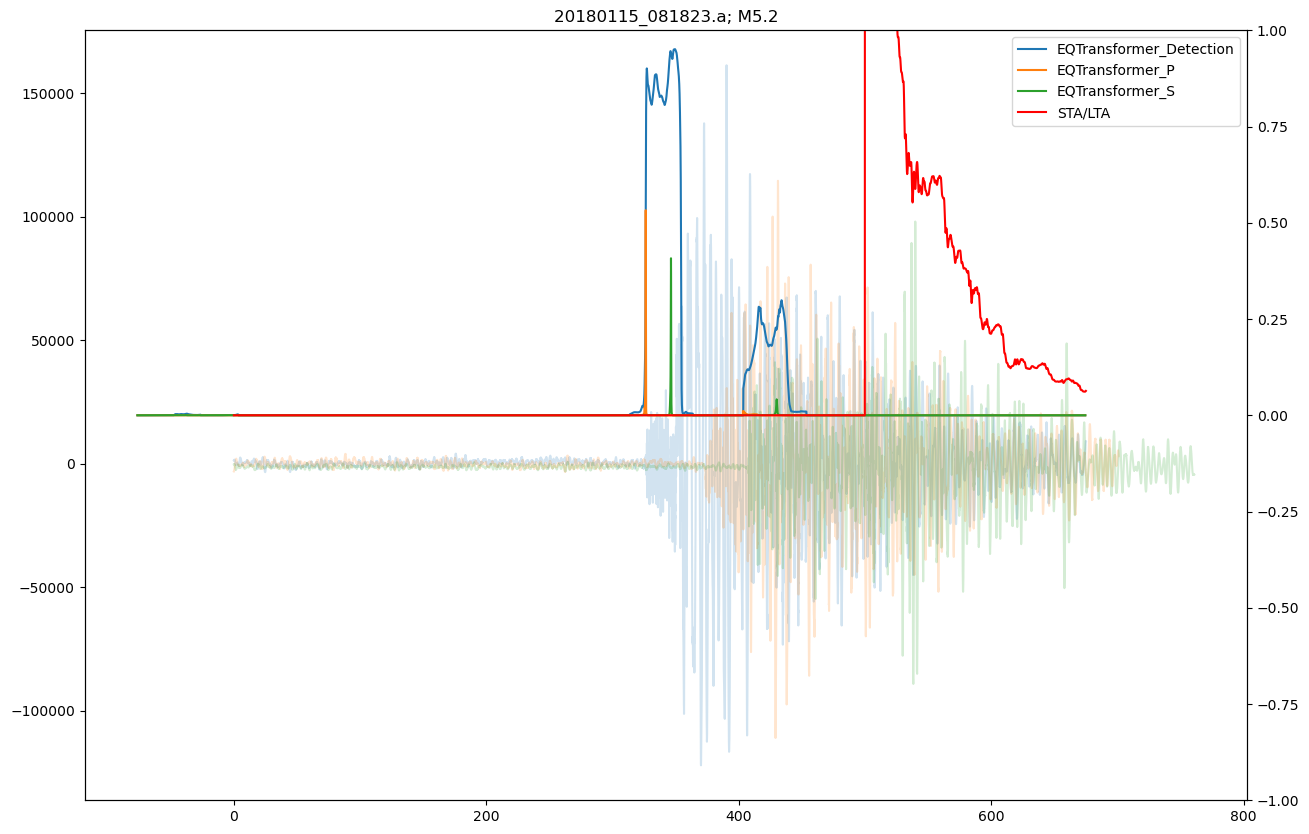

20180111_170318.a


/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


15 Trace(s) in Stream:
G.HDC.00.EQTransformer_Detection | 2018-01-11T16:57:00.950000Z - 2018-01-11T17:09:43.840000Z | 100.0 Hz, 76290 samples
G.HDC.00.EQTransformer_P         | 2018-01-11T16:57:00.950000Z - 2018-01-11T17:09:43.840000Z | 100.0 Hz, 76290 samples
G.HDC.00.EQTransformer_S         | 2018-01-11T16:57:00.950000Z - 2018-01-11T17:09:43.840000Z | 100.0 Hz, 76290 samples
NU.ACON..EQTransformer_Detection | 2018-01-11T16:58:22.260000Z - 2018-01-11T17:08:15.520000Z | 100.0 Hz, 59327 samples
NU.ACON..EQTransformer_P         | 2018-01-11T16:58:22.260000Z - 2018-01-11T17:08:15.520000Z | 100.0 Hz, 59327 samples
NU.ACON..EQTransformer_S         | 2018-01-11T16:58:22.260000Z - 2018-01-11T17:08:15.520000Z | 100.0 Hz, 59327 samples
NU.BLUN..EQTransformer_Detection | 2018-01-11T16:58:21.780000Z - 2018-01-11T17:08:14.520000Z | 100.0 Hz, 59275 samples
NU.BLUN..EQTransformer_P         | 2018-01-11T16:58:21.780000Z - 2018-01-11T17:08:14.520000Z | 100.0 Hz, 59275 samples
NU.BLUN..EQTransformer_S 

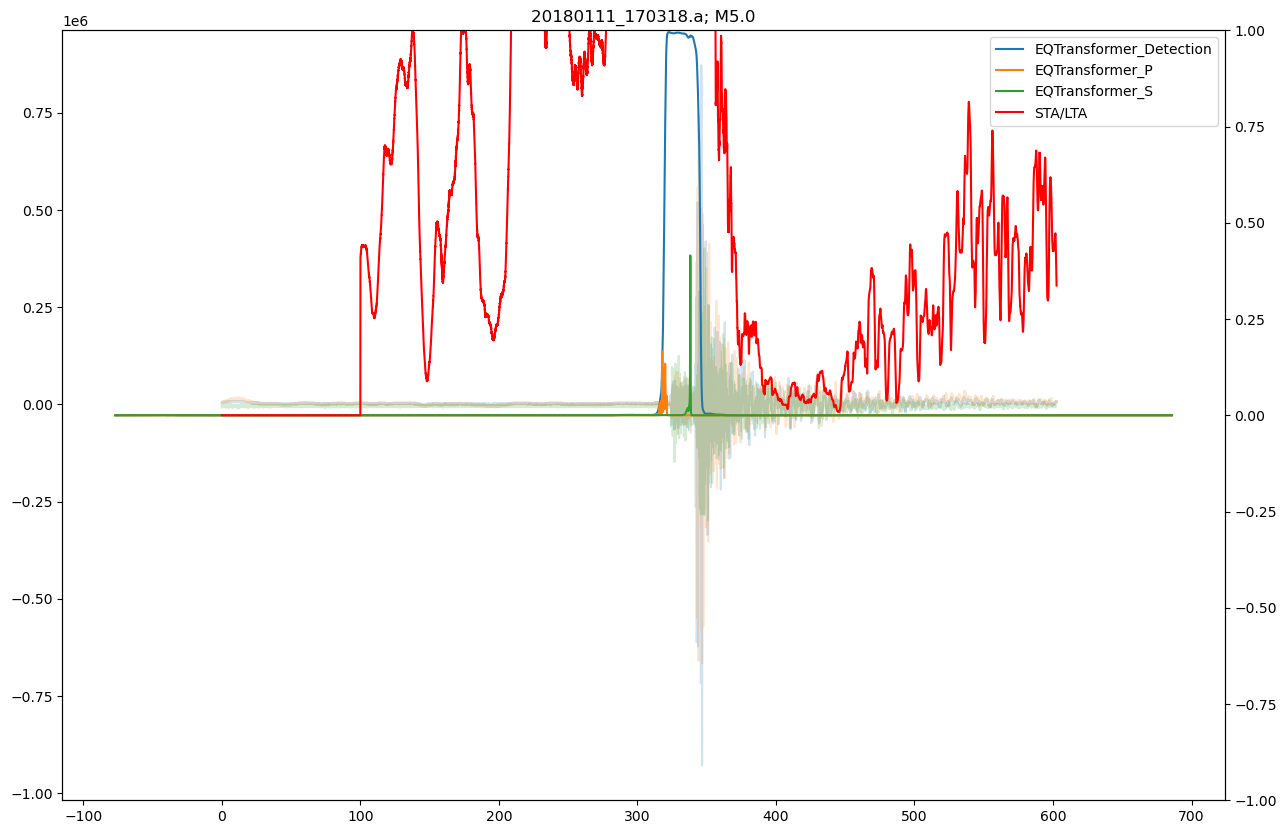

In [32]:
count = 0
for eq_name, mag in zip(eq_with_data, mags):
	if count >=10:
		break
	try:
		print(eq_name)
		stream = obspy.read(root + '/' + eq_name + '/data/*/*')
		annotations = model.annotate(stream)
		print(annotations)
		print('earthquake number' + str(count) + 'done. It was' + eq_name)
		
		fig = plt.figure(figsize=(15, 10))
		axs = fig.subplots(1, 1, sharex=True, gridspec_kw={'hspace': 0})
		ax2 = axs.twinx()

		offset = annotations[0].stats.starttime - stream[0].stats.starttime
		for i in range(3):
			axs.plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel, alpha=0.2)
			if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
				ax2.plot(annotations[i].times() + offset, annotations[i].data, label=annotations[i].stats.channel)

		# Calculate STA/LTA
		sta_lta = obspy.signal.trigger.classic_sta_lta(stream[0].data, nsta=500, nlta=10000)
		ax2.plot(stream[0].times(), sta_lta, label='STA/LTA', color='r')
		ax2.set_ylim(-1,1)
		ax2.legend()

		axs.set_title(eq_name + '; M' + str(mags[count]))
		plt.savefig('/home/earthquakes1/homes/Rebecca/phd/seismo_det/figures/pick_uncert_figures/' + str(mag) + '_' + eq_name + '.png')
		plt.show()
		plt.close()
	except Exception as e:
		print(e)
		continue
	count += 1

In [30]:
mags

[5.0,
 5.06,
 5.75,
 5.4,
 5.0,
 6.3,
 5.8,
 5.8,
 5.2,
 5.0,
 5.1,
 5.0,
 5.2,
 5.3,
 5.1,
 5.0,
 5.0,
 5.2,
 5.2,
 5.1,
 5.1,
 5.2,
 5.4,
 5.0,
 5.0,
 5.4,
 5.1,
 5.0,
 5.1,
 5.1,
 5.6,
 5.2,
 5.0,
 5.0,
 5.0,
 5.1,
 5.3,
 5.0,
 5.6,
 5.2,
 5.1,
 5.9,
 5.4,
 5.1,
 5.1,
 5.1,
 5.0,
 5.1,
 5.4,
 5.2,
 5.2,
 5.2,
 5.1,
 5.0,
 5.1,
 5.2,
 5.5,
 5.2,
 5.5,
 5.4,
 5.3,
 5.0,
 5.7,
 5.3,
 5.2,
 5.1,
 5.0,
 5.8,
 5.2,
 5.2,
 5.5,
 6.0,
 5.1,
 5.0,
 5.3,
 5.0,
 5.1,
 5.2,
 5.4,
 5.0,
 7.1,
 5.1,
 5.3,
 6.1,
 5.3,
 5.2,
 5.1,
 5.0,
 5.1,
 5.2,
 5.0,
 5.4,
 5.2,
 5.4,
 5.4,
 5.0,
 5.0,
 5.2,
 5.0,
 5.4,
 5.3,
 5.1,
 5.0,
 5.1,
 5.5,
 5.7,
 5.6,
 6.1,
 5.0,
 5.5,
 5.1,
 5.0,
 5.1,
 5.0,
 5.0,
 5.1,
 6.8,
 5.1,
 5.0,
 5.0,
 5.1,
 5.3,
 5.2,
 5.1,
 5.6,
 5.0,
 5.1,
 5.0,
 5.1,
 5.1,
 5.0,
 5.4,
 5.2,
 5.1,
 5.8,
 6.4,
 6.3,
 5.1,
 5.6,
 5.4,
 5.6,
 5.8,
 5.2,
 5.2,
 5.3,
 6.7,
 6.2,
 5.3,
 5.1,
 5.0,
 5.0,
 5.0,
 5.3,
 5.0,
 5.0,
 5.0,
 5.0,
 5.5,
 5.2,
 5.2,
 5.4,
 5.1,
 5.0,
 5.0,
 5.0,
 5.0,
 5